<h1><center>Fruit 360 Dataset</center></h1>

<center><img src="https://www.researchgate.net/publication/342916129/figure/fig2/AS:913043131207680@1594697854025/Illustration-of-few-images-from-Fruits-360-dataset.ppm"></center>

# **Contents**

1. [Import data and python packages](#t1.)


2. [Data visualization](#t2.)


3. [Classification (CNN)](#t3.)


4. [Prediction](#t4.)

<a id="t1."></a>
# 1. Import data and python packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
import os
from IPython.display import clear_output

In [2]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models

In [3]:
from sklearn.preprocessing import LabelEncoder

In [4]:
sample_size = 200
width = 50
height = 50

In [5]:
files = []
adress = '/kaggle/input/fruits/fruits-360/Training/{}'
os.chdir('/kaggle/input/fruits/fruits-360/Training')
for i in os.listdir(os.getcwd()):
    files.append(i)

In [6]:
data = {}
for f in files:
    data[f]=[]
for col in files:
    os.chdir(adress.format(col))
    for i in os.listdir(os.getcwd()):
        if i.endswith('.jpg'):
            data[col].append(i)

In [7]:
start = time.time()
image_data = []
image_target = []

for title in files:
    os.chdir(adress.format(title))
    counter = 0
    for i in data[title]:
        img = cv2.imread(i)
        image_data.append(cv2.resize(img,(width, height)))
        image_target.append(title)
        counter += 1
        if counter == sample_size:
            break
    clear_output(wait=True)
    print("Compiled Class",title)
calculate_time = time.time() - start    
print("Calculate Time",round(calculate_time,5))

Compiled Class Tomato 2
Calculate Time 107.98812


In [8]:
start = time.time()
image_data_test = []
image_target_test = []

for title in files:
    os.chdir(adress.format(title))
    sayac = 0
    for i in data[title][sample_size:]:
        img = cv2.imread(i)
        image_data_test.append(cv2.resize(img,(width, height)))
        image_target_test.append(title)
        sayac += 1
        if sayac == 50:
            break
    clear_output(wait=True)
    print("Compiled Class",title)
calculate_time = time.time() - start    
print("Calculate Time",round(calculate_time,5))

Compiled Class Tomato 2
Calculate Time 27.58187


In [9]:
image_data = np.array(image_data)
size = image_data.shape[0]
image_data.shape

(26200, 50, 50, 3)

In [10]:
image_data_test = np.array(image_data_test)
size = image_data_test.shape[0]
image_data_test.shape

(6550, 50, 50, 3)

<a id="t2."></a>
# 2. Data visualization

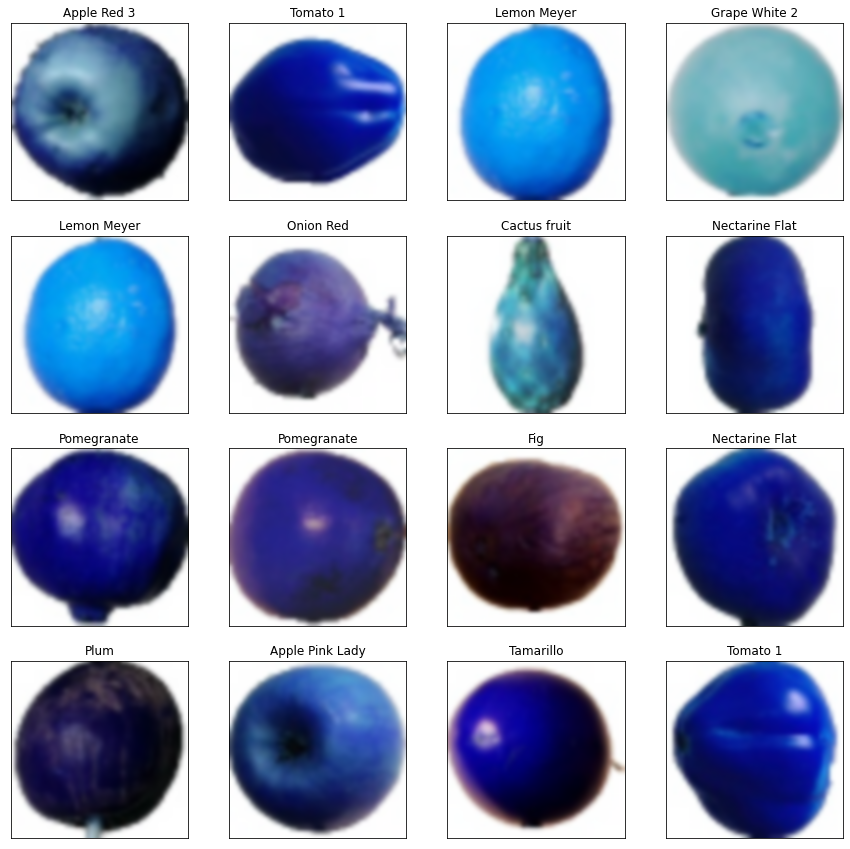

In [11]:
plt.figure(figsize=(15,15))
for i in range(1,17):
    fig = np.random.choice(np.arange(1,size+1))
    plt.subplot(4,4,i)
    plt.imshow(image_data[fig], cmap="gray", origin='upper', interpolation = 'bicubic')
    plt.title(image_target[fig])
    plt.xticks([]), plt.yticks([])
plt.show()

<a id="t3."></a>
# 3. Classification (CNN)

In [12]:
labels = LabelEncoder()
labels.fit(image_target)

LabelEncoder()

In [13]:
train_images = image_data / 255.0
train_labels = labels.transform(image_target)

In [14]:
test_images = image_data_test / 255.0
test_labels = labels.transform(image_target_test)

In [15]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(width,height,3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [16]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(131))

In [17]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=8, 
                    validation_data=(test_images, test_labels))

Epoch 1/8
819/819 [==============================] - 56s 67ms/step - loss: 2.6073 - accuracy: 0.3963 - val_loss: 0.1776 - val_accuracy: 0.9429
Epoch 2/8
819/819 [==============================] - 54s 66ms/step - loss: 0.1823 - accuracy: 0.9393 - val_loss: 0.0742 - val_accuracy: 0.9776
Epoch 3/8
819/819 [==============================] - 53s 65ms/step - loss: 0.0868 - accuracy: 0.9744 - val_loss: 0.0592 - val_accuracy: 0.9815
Epoch 4/8
819/819 [==============================] - 53s 65ms/step - loss: 0.0659 - accuracy: 0.9796 - val_loss: 0.0669 - val_accuracy: 0.9774
Epoch 5/8
819/819 [==============================] - 54s 66ms/step - loss: 0.0480 - accuracy: 0.9845 - val_loss: 0.0107 - val_accuracy: 0.9973
Epoch 6/8
819/819 [==============================] - 54s 66ms/step - loss: 0.0265 - accuracy: 0.9929 - val_loss: 0.0216 - val_accuracy: 0.9936
Epoch 7/8
819/819 [==============================] - 54s 65ms/step - loss: 0.0109 - accuracy: 0.9973 - val_loss: 0.0260 - val_accuracy: 0.9924

205/205 - 3s - loss: 0.1461 - accuracy: 0.9579


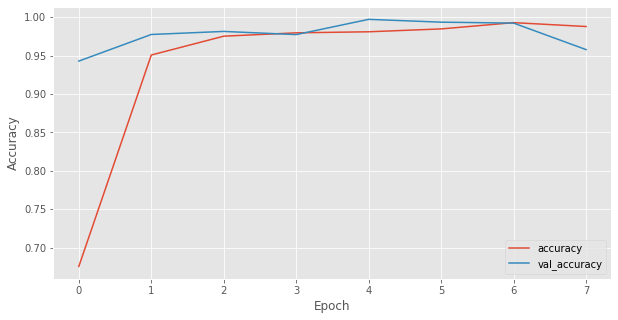

In [18]:
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

<a id="t4."></a>
# 4. Prediction

In [19]:
def Prediction(image):
    
    global width, height, files, labels
    
    #img = cv2.resize(image,(width,height))
    
    test = img / 255.0
    
    pred = model.predict(np.array([image])).argmax()
    
    return labels.inverse_transform([pred])[0]

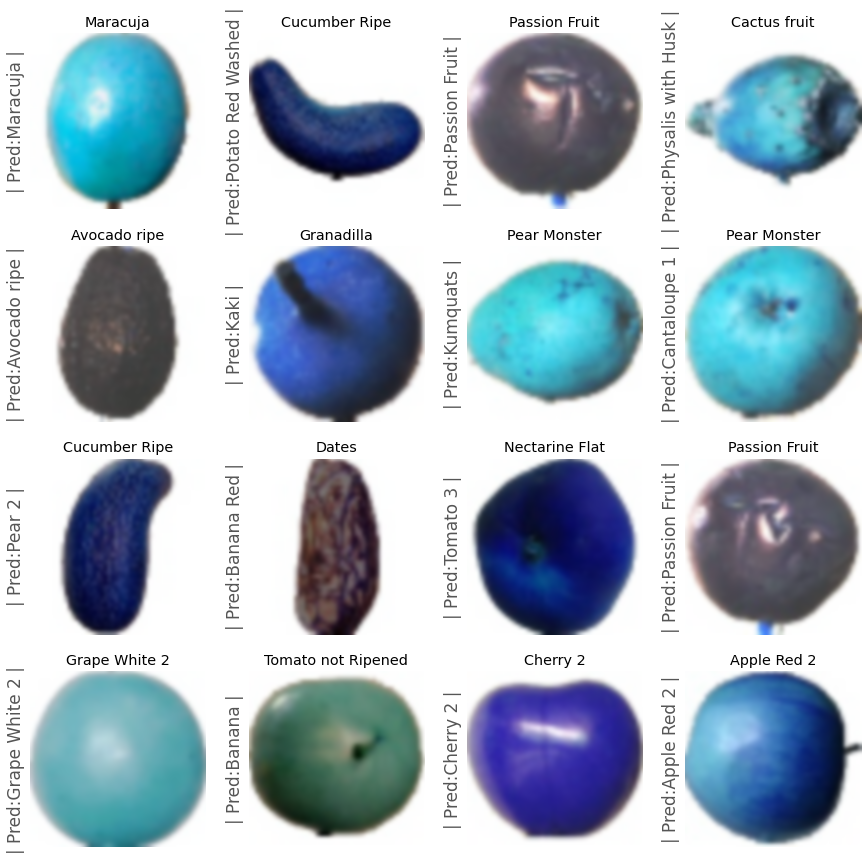

In [20]:
plt.figure(figsize=(15,15))
for i in range(1,17):
    fig = np.random.choice(np.arange(1,size+1))
    plt.subplot(4,4,i)
    plt.imshow(image_data[fig], cmap="gray", origin='upper', interpolation = 'bicubic')
    plt.title(image_target[fig])
    plt.ylabel("| Pred:{} |".format(Prediction(image_data[fig])),fontsize=17)
    plt.xticks([]), plt.yticks([])
plt.show()